In [1]:
import os, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from typing import Dict, Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import torchvision.utils as vutils

from transformers import DistilBertModel, DistilBertTokenizerFast
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  PyTorch: {torch.__version__}')
print(f'  Cihaz  : {DEVICE}')

  PyTorch: 2.10.0+cu128
  Cihaz  : cuda


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

DATA_DIR = os.path.join(path, 'fashion-dataset')
CSV_PATH = os.path.join(DATA_DIR, 'styles.csv')
IMG_DIR  = os.path.join(DATA_DIR, 'images')

df = pd.read_csv(CSV_PATH, on_bad_lines='skip')
print(f'Rows: {len(df):,}  |  Columns: {list(df.columns)}')
df.head(3)


Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
Rows: 44,424  |  Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch


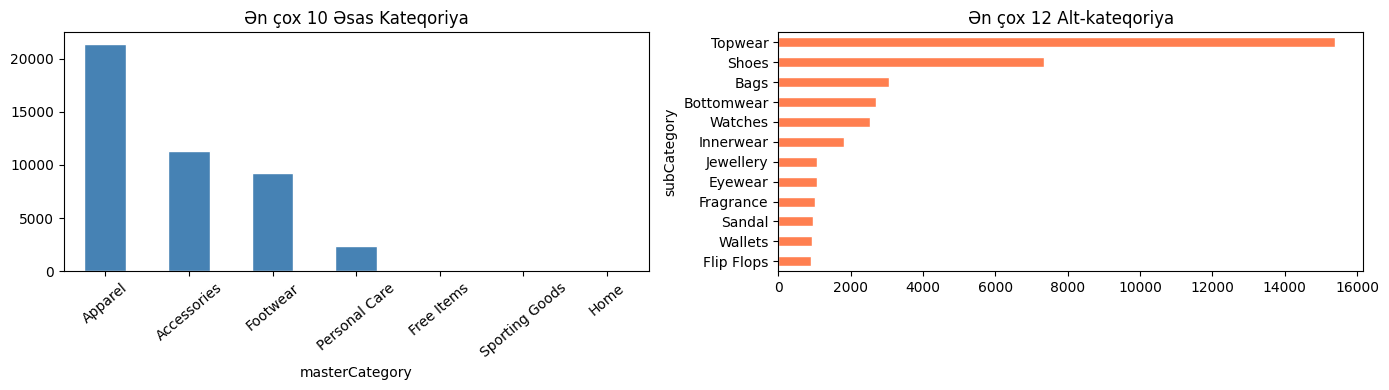

In [3]:
#Kateqoriya paylanması
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['masterCategory'].value_counts().head(10).plot.bar(
    ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ən çox 10 Əsas Kateqoriya', fontsize=12)
axes[0].tick_params(axis='x', rotation=40)

df['subCategory'].value_counts().head(12).plot.barh(
    ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ən çox 12 Alt-kateqoriya', fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
#Bu o deməkdir ki, model bu kateqoriyaları çox yaxşı tanıyacaq
#amma azlıqda qalanları (məsələn, Wallets və ya Belts) tanımaqda çətinlik çəkə bilər.

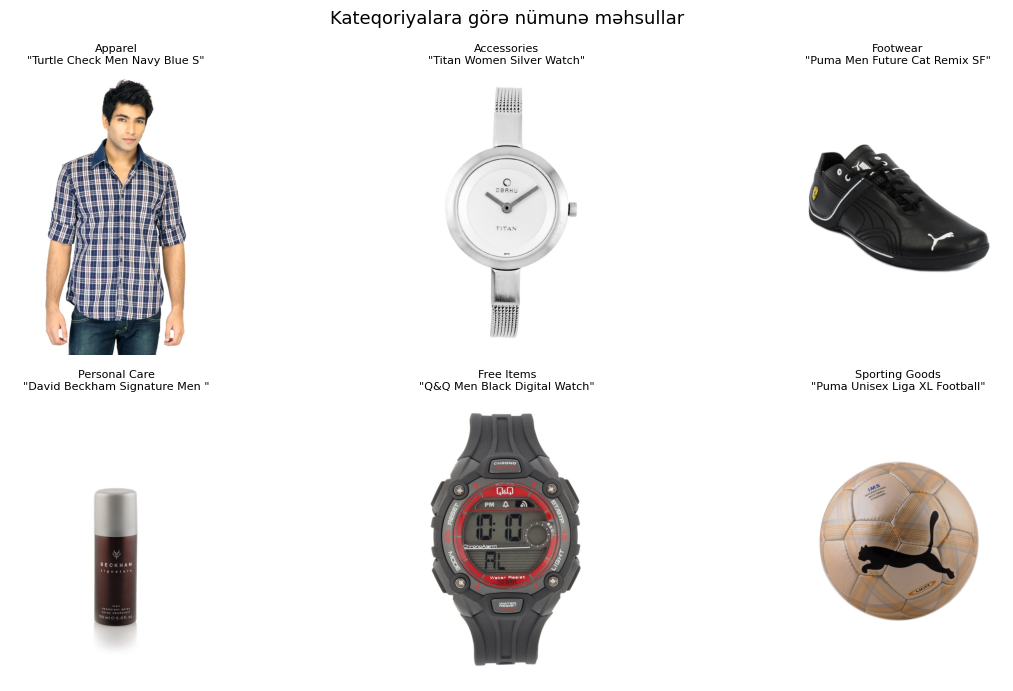

In [4]:
#6 kateqoriya üçün nümunə şəkillər
cats = df['masterCategory'].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, cat in zip(axes.flat, cats):
    sub = df[df['masterCategory'] == cat].dropna(subset=['id'])
    for _, row in sub.iterrows():
        p = os.path.join(IMG_DIR, f"{int(row['id'])}.jpg")
        if os.path.isfile(p):
            ax.imshow(Image.open(p).convert('RGB'))
            ax.set_title(f'{cat}\n"{str(row["productDisplayName"])[:28]}"', fontsize=8)
            ax.axis('off')
            break

plt.suptitle('Kateqoriyalara görə nümunə məhsullar', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
TOP_N_CLASSES   = 10
IMAGE_SIZE      = 224
MAX_TEXT_LEN    = 64
TOKENIZER_NAME  = 'distilbert-base-uncased'
IMAGENET_MEAN   = [0.485, 0.456, 0.406]
IMAGENET_STD    = [0.229, 0.224, 0.225] #Çünki ResNet-18 ImageNet datasetində təlim keçərkən bu rəqəmlərlə normallaşdırılıbdi

def get_transforms(split: str):
    """ 'train' üçün şəkil artırma (augmentation), 'test' üçün yalnız standart hazırlıq. """

    if split == 'train':
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),

     # '''   transforms.RandomCrop(IMAGE_SIZE),       # Mərkəzdən asılılığı qırır
     #       transforms.RandomHorizontalFlip(p=0.5),  # 50% ehtimalla şəkli güzgü kimi çevirir
     #       transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2), # İşığı və rəngi dəyişir
     #       transforms.RandomRotation(10),           # Şəkli maksimum 10 dərəcə döndərir '''


        ])
        # 'val' və ya 'test' üçün sadəcə şəkli hazırlayır
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

In [18]:
def build_text(name, article='', colour='', season='', year=''):
    """Mövcud sütunları bir cümləyə birləşdirir
    modelə kateqoriyanı daha dəqiq təyin etməyə kömək edir (Future Engineering)"""
    parts = [str(name)]
    for val in [article, colour, season, year]:
     s = str(val).strip()
     if s and s not in ('nan', ''):
      parts.append(s.lower())
    return ' | '.join(parts)

def load_data(csv_path: str, img_dir: str, top_n: int = 10):

    #CSV-ni oxu və lazımsız sütunları atmaq
 df = pd.read_csv(csv_path, on_bad_lines='skip')
 df = df[['id', 'productDisplayName', 'masterCategory', 'articleType', 'baseColour']].copy()
 df.dropna(inplace=True) # Boş xanaları olan sətirləri sil

  #ilk N kateqoriyanı seç
 top_cats = df['masterCategory'].value_counts().head(top_n).index
 df = df[df['masterCategory'].isin(top_cats)].copy()

    #Şəkil yollarını yarat və faylı olmayanları sil
 df['image_path'] = df['id'].apply(lambda x: os.path.join(img_dir, f"{x}.jpg"))
 df = df[df['image_path'].apply(os.path.exists)].reset_index(drop=True)


#Kateqoriyaları rəqəmlərə çevir (Label Encoding)
 cats = sorted(df['masterCategory'].unique())
 label2id = {cat: i for i, cat in enumerate(cats)}
 id2label = {i: cat for cat, i in label2id.items()}
 df['label'] = df['masterCategory'].map(label2id)

 df['text'] = df['productDisplayName'] + " " + df['articleType'] + " " + df['baseColour']

 print(f"Datasetde: {len(df)} sətir, {len(label2id)} sinif.")
 return df, label2id, id2label

df, label2id, id2label =load_data(CSV_PATH, IMG_DIR, top_n=TOP_N_CLASSES)

for idx, name in sorted(id2label.items()):
 print(f'  {idx:>2}  {name:<22}  {(df["label"]==idx).sum():>5} nümunə')

Datasetde: 44402 sətir, 7 sinif.
   0  Accessories             11272 nümunə
   1  Apparel                 21386 nümunə
   2  Footwear                 9219 nümunə
   3  Free Items                105 nümunə
   4  Home                        1 nümunə
   5  Personal Care            2394 nümunə
   6  Sporting Goods             25 nümunə


In [19]:
class_counts = df['label'].value_counts()

#Nümunə sayıçox olan kateqoriyaları seçirik
valid_classes = class_counts[class_counts >= 10].index

# Dataseti filtrliyirik
df = df[df['label'].isin(valid_classes)].copy()

'''Etiketləri yenidən kodlayırıq
Çünki bəzi siniflər silindiyi üçün label indekslərində boşluq yarana bilər'''
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])


In [20]:
df.head(3)

,id,productDisplayName,masterCategory,articleType,baseColour,image_path,label,text
0,15970,Turtle Check Men Navy Blue Shirt,Apparel,Shirts,Navy Blue,/kaggle/input/fashion-product-images-dataset/f...,1,Turtle Check Men Navy Blue Shirt Shirts Navy Blue
1,39386,Peter England Men Party Blue Jeans,Apparel,Jeans,Blue,/kaggle/input/fashion-product-images-dataset/f...,1,Peter England Men Party Blue Jeans Jeans Blue
2,59263,Titan Women Silver Watch,Accessories,Watches,Silver,/kaggle/input/fashion-product-images-dataset/f...,0,Titan Women Silver Watch Watches Silver


In [21]:
tokenizer = DistilBertTokenizerFast.from_pretrained(TOKENIZER_NAME)

class FashionDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df) # Cəmi neçə məhsul olduğunu deyir

    def __getitem__(self, idx):
        #Məlumatı sətir-sətir götür

        row = self.df.iloc[idx]
        try:     #Şəkli yüklə və emal et (Resize, Normalize və s.)
            img = Image.open(row['image_path']).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), 128) # Şəkil xarabdırsa, boz kvadrat qoy

        image_tensor = self.transform(img)

        #Mətni rəqəmlərə (Tokenlərə) çevir
        text_data = tokenizer(
            str(row['text']),
            max_length=64,
            padding='max_length',      # Qısa mətnlərin sonuna 0-lar əlavə et
            truncation=True,           # Uzun mətnləri kəs
            return_tensors='pt'
        )
        #Modelə paket halında göndər
        return {
            'image': image_tensor,
            'input_ids': text_data['input_ids'].squeeze(0),      # Sözlərin ID-ləri
            'attention_mask': text_data['attention_mask'].squeeze(0), # Hansı hissə mətndir, hansı 0-dır?
            'label': torch.tensor(row['label'], dtype=torch.long) # Kateqoriya (məs: 0, 1, 2)
        }


In [42]:
BATCH_SIZE  = 32
NUM_WORKERS = 0

'''Stratified split: 70 / 15 / 15 eyni faizlərin qorunmasını təmin edir
 Əks halda, test hissəsinə heç Şərf falan  düşməyə bilərdi'''

train_idx, tmp_idx = train_test_split(df.index, test_size=0.30, stratify=df['label'], random_state=42)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=df.loc[tmp_idx, 'label'], random_state=42)

# Dataset obyektlərini yarat
train_ds = FashionDataset(df.loc[train_idx], get_transforms('train'))
val_ds   = FashionDataset(df.loc[val_idx],   get_transforms('val'))
test_ds  = FashionDataset(df.loc[test_idx],  get_transforms('test'))

#Azlıqda qalan kateqoriyalar üçün çəki hesabla (Balanslaşdırma)
class_counts = np.bincount(df.loc[train_idx, 'label'])
weights = 1.0 / class_counts[df.loc[train_idx, 'label']]
sampler = WeightedRandomSampler(weights, num_samples=len(train_ds), replacement=True)

#  DataLoader-ləri (Yük maşınlarını) işə sal
common   = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=False)
train_dl = DataLoader(train_ds, shuffle=True,  **common)
val_dl   = DataLoader(val_ds,   shuffle=False, **common)
test_dl  = DataLoader(test_ds,  shuffle=False, **common)

# Yoxlama: İlk paketdə nə var?
batch = next(iter(train_dl))
print(f"Şəkillər paketi: {batch['image'].shape}")

Şəkillər paketi: torch.Size([32, 3, 256, 256])


In [43]:
class ImageEncoder(nn.Module):
    """
    ResNet-18 backbone.
    stem + layer1 + layer2 ümumi vizual xüsusiyyətləri dondurdum ki oyrenmeye luzum yoxdu
    • layer3 + layer4    spesifik seyleri oyrenir
    • FC qat silinib, yerinə LayerNorm+Linear+GELU əlavə edilib
    Çıxış: (B, out_dim)
    """

    def __init__(self, out_dim=512):
        super().__init__()

        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


        for name, p in base.named_parameters():
            if 'layer3' not in name and 'layer4' not in name:
                p.requires_grad = False


        self.backbone = nn.Sequential(*list(base.children())[:-1])


        self.proj = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(512),
            nn.Linear(512, out_dim),
            nn.ReLU()
            #nn.GELU() ReLU-dan dahaağıllı
        )

    def forward(self, x):
        features = self.backbone(x) # Şəkildən xüsusiyyətləri çıxardir
        return self.proj(features)  # Onları 512 rəqəmə sıxışdır


        # Sınaq
_ie = ImageEncoder(512)
print('ImageEncoder :', _ie(torch.randn(2, 3, 224, 224)).shape)

ImageEncoder : torch.Size([2, 512])


In [25]:
class TextEncoder(nn.Module):
    """
    DistilBERT backbone
    transformer layer 0-4 dondurruq ki ing dilin bos bosuna yox ele terminleri oyrensin
    transformer layer 5  ÖYRƏNİR  son qat
    Pooling CLS tokeni (index=0) yazaraq Bütün batch, 1-ci token, bütün 768 ölçü) məhz həmin xülasə vektorunu götürürem
    Standard BERT-də pooler_output olsa da, DistilBERTdə bu yoxdur.
    Çıxış:(B, out_dim)
    """
    def __init__(self, out_dim=512):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained(TOKENIZER_NAME)

        for p in self.bert.parameters():
            p.requires_grad_(False)
        # Yalnız son transformer qatını açıq burax
        for p in self.bert.transformer.layer[-1].parameters():
            p.requires_grad_(True)

        hidden = self.bert.config.hidden_size   # 768 i 512 ile sixsin
        self.proj = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(0.2), #qoyaqki overfit olmasin
            nn.Linear(hidden, out_dim),
            nn.ReLU()
            #nn.GELU(),
        )

    def forward(self, input_ids, attention_mask):
        out     = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = out.last_hidden_state[:, 0, :]   # (B, 768)
        return self.proj(cls_emb)                  # (B, out_dim)

# Sınaq
_te  = TextEncoder(512)
_ids = torch.randint(0, 100, (2, 64))
_msk = torch.ones(2, 64, dtype=torch.long)
print('TextEncoder:', _te(_ids, _msk).shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextEncoder: torch.Size([2, 512])


## Multi-Model Classifier
Artıq əlimizdə 512 ölçülü Görüntü vektoru və 512 ölçülü Mətn vektoru var. İndi bunları tək bir sey altında, əsas Multi-Modal Classifier klassında birləşdirmək lazimdir

In [27]:
class GatedFusion(nn.Module):
  def __init__(self, d=512):
        super().__init__()
        self.gate = nn.Sequential(nn.Linear(2*d, 2*d), nn.Sigmoid())
        self.attn = nn.MultiheadAttention(embed_dim=d, num_heads=4,
                                          batch_first=True, dropout=0.1)
        self.norm = nn.LayerNorm(d)
        self.proj = nn.Sequential(nn.Linear(2*d, 2*d), nn.ReLU(), nn.LayerNorm(2*d))

  def forward(self, v_img, v_txt):
        # Gate
        g_img, g_txt = self.gate(torch.cat([v_img, v_txt], -1)).chunk(2, -1)
        gi, gt = g_img * v_img, g_txt * v_txt

  # Cross-attention
        att, _ = self.attn(gi.unsqueeze(1), gt.unsqueeze(1), gt.unsqueeze(1))
        att    = self.norm(att.squeeze(1) + gi)   # residual


        return self.proj(torch.cat([att, gt], -1))

'''Bu o deməkdir ki, model şəkildəki xüsusiyyətləri götürür və mətndə onlara uyğun gələn məlumatları axtarır'''

'Bu o deməkdir ki, model şəkildəki xüsusiyyətləri götürür və mətndə onlara uyğun gələn məlumatları axtarır'

# Tam Model

In [28]:
class MultiModalClassifier(nn.Module):
    """
    ImageEncoder(512)
                        GatedFusion(1024) olur MLP olur logits(N)
    TextEncoder(512)
    """
    def __init__(self, num_classes, embed_dim=512, dropout=0.3):
        super().__init__()
        self.image_enc  = ImageEncoder(embed_dim)
        self.text_enc   = TextEncoder(embed_dim)
        self.fusion     = GatedFusion(embed_dim)
        fused           = 2 * embed_dim   # 1024

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused, 512), nn.BatchNorm1d(512), nn.GELU(),
            nn.Dropout(dropout / 2), #Regularizationdu
            nn.Linear(512, 256), nn.GELU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, input_ids, attention_mask):
        v_img  = self.image_enc(image)
        v_txt  = self.text_enc(input_ids, attention_mask)
        fused  = self.fusion(v_img, v_txt)
        return self.classifier(fused)


NUM_CLASSES = len(label2id)
model = MultiModalClassifier(num_classes=NUM_CLASSES).to(DEVICE)


all_params       = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelin ümumi böyüklüyü: {all_params:,} parametr")
print(f"Həqiqətən öyrədilən hissə: {trainable_params:,} parametr")
print(f"Öyrədilmə faizi: {100 * trainable_params / all_params:.1f}%")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelin ümumi böyüklüyü: 82,010,183 parametr
Həqiqətən öyrədilən hissə: 22,052,103 parametr
Öyrədilmə faizi: 26.9%


In [29]:
model.eval()
mini = {k: v[:4].to(DEVICE) for k, v in sample_batch.items()}
with torch.no_grad():
    out = model(mini['image'], mini['input_ids'], mini['attention_mask'])
print(f'Logit : {out.shape} (batch=4, sinif={NUM_CLASSES})')

Logit : torch.Size([1, 7]) (batch=4, sinif=7)


# Training Loop

In [34]:
# Hiperparametrlərimiz
LR       = 3e-4
EPOCHS   = 1
PATIENCE = 5
SAVE_DIR = Path('checkpoints')
SAVE_DIR.mkdir(exist_ok=True)

# Diferensial öyrənmə sürəti
# Pretrained qatlar kiçik LR;  Yeni qatlar böyük LR
optimizer = AdamW([        #BERT və ResNet üçün AdamW Weight Decay ilə ən yaxşı seçimdi
    {'params': model.image_enc.backbone.parameters(), 'lr': LR * 0.1},
    {'params': model.image_enc.proj.parameters(),     'lr': LR},
    {'params': model.text_enc.bert.parameters(),      'lr': LR * 0.1}, #Fine tuningle onlarin unutmagi engelleyek
    {'params': model.text_enc.proj.parameters(),      'lr': LR},
    {'params': model.fusion.parameters(),             'lr': LR},
    {'params': model.classifier.parameters(),         'lr': LR},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)  #modelin təlimin sonunda optimal nöqtədən uzaqlaşmasının qarşısını alır
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) #etiketi yumsaldirki daha cevik olsun no overconfidience
scaler    = GradScaler()

In [35]:
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    loss_sum, correct, n = 0.0, 0, 0

    for batch in loader:
        # Datanı birbaşa döngü daxilində GPU-ya ötürürük
        img   = batch['image'].to(DEVICE)
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        label = batch['label'].to(DEVICE)
        optimizer.zero_grad()

        with autocast():
            logits = model(img, ids, mask)
            loss   = criterion(logits, label)

        scaler.scale(loss).backward() # Səhvi  qatlara ötürür
        scaler.unscale_(optimizer) # Qradientləri normal ölçüyə qaytarır
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

         # Metrikaları hesabla
        bs        = label.size(0)
        loss_sum += loss.item() * bs
        correct  += (logits.argmax(-1) == label).sum().item()
        n        += bs

    return loss_sum / n, correct / n

In [46]:
def evaluate(model, loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():  #Gradient hesablanmasın, yaddaş qənaət etmek
        for batch in loader:
            img    = batch['image'].to(DEVICE)
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            logits = model(img, ids, mask)
            loss   = criterion(logits, labels)  # indi işlədir

            total_loss += loss.item()
            preds = logits.argmax(dim=-1)

            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy, all_preds, all_labels

In [47]:
best_f1 = 0.0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    #Qiymətləndirmə
    tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion,scaler)
    vl_loss, vl_acc, preds, labels = evaluate(model, val_dl,criterion)

    '''Metrikanı tapaq F1-score Macro-F1 hər bir sinfə
    (az və ya çox olmasından asılı olmayaraq) eyni dərəcədə önəm verir
    Əgər bu rəqəm yüksəlirsə, deməli modelin hər şeyi öyrənir.'''

    vl_f1 = f1_score(labels, preds, average='macro')
    scheduler.step() # Öyrənmə sürətini tənzimləyir

    print(f"Epoch {epoch}: Train Acc: {tr_acc:.27f}  Val F1: {vl_f1:.4f}")

    #Ən yaxşı modeli yadda saxla
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')

    else:
        patience_counter += 1

    #Vaxtında dayandır (Early Stopping)
    if patience_counter >= PATIENCE:

        break

Epoch 1: Train Acc: 0.998680823680823670507322731  Val F1: 0.9945


In [38]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  PyTorch: {torch.__version__}')
print(f'  Cihaz  : {DEVICE}')

  PyTorch: 2.10.0+cu128
  Cihaz  : cuda
